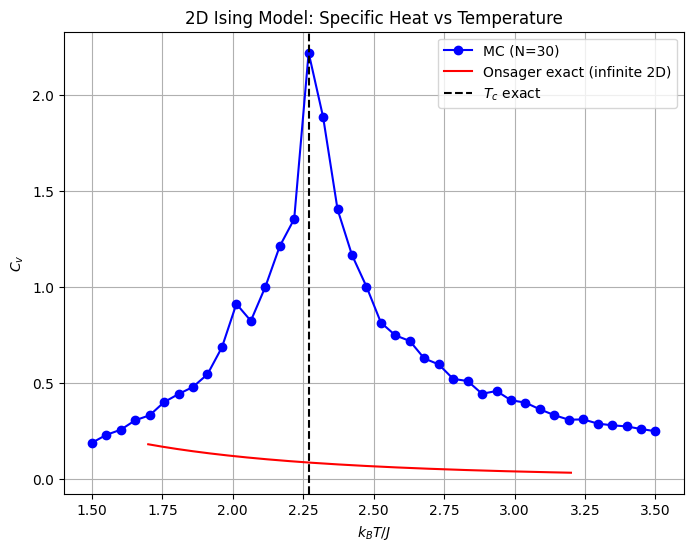

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 2D Ising Model --- Metropolis Monte Carlo
# ============================================================

def initial_lattice(N):
    return np.random.choice([-1, 1], (N, N))


def delta_energy(lattice, i, j, J=1.0):
    """
    ΔE for flipping spin at (i, j) in a 2D periodic lattice.
    """
    N = lattice.shape[0]
    s = lattice[i, j]
    nn = (
        lattice[(i+1) % N, j] +
        lattice[(i-1) % N, j] +
        lattice[i, (j+1) % N] +
        lattice[i, (j-1) % N]
    )
    return 2 * J * s * nn


def metropolis_step(lattice, beta):
    """
    One Metropolis sweep (N*N attempted updates).
    """
    N = lattice.shape[0]
    for _ in range(N*N):
        i = np.random.randint(0, N)
        j = np.random.randint(0, N)
        dE = delta_energy(lattice, i, j)
        if dE < 0 or np.random.rand() < np.exp(-beta*dE):
            lattice[i, j] *= -1


def compute_energy(lattice, J=1.0):
    """
    Computes total energy of 2D Ising lattice (periodic).
    """
    N = lattice.shape[0]
    E = 0
    for i in range(N):
        for j in range(N):
            S = lattice[i, j]
            nn = lattice[(i+1) % N, j] + lattice[i, (j+1) % N]
            E += -J * S * nn
    return E


# ============================================================
# Run simulation for a range of temperatures
# ============================================================

N = 30            # increasing N makes Cv peak sharper
J = 1.0
n_eq = 5000       # equilibration sweeps
n_meas = 5000     # measurement sweeps

T_values = np.linspace(1.5, 3.5, 40)
Cv_values = []

for T in T_values:
    beta = 1.0 / T
    lattice = initial_lattice(N)

    # Equilibration
    for _ in range(n_eq):
        metropolis_step(lattice, beta)

    # Measurement
    E_list = []
    for _ in range(n_meas):
        metropolis_step(lattice, beta)
        E_list.append(compute_energy(lattice))

    E_arr = np.array(E_list)
    E_mean = np.mean(E_arr)
    E2_mean = np.mean(E_arr**2)

    # Specific heat per spin
    Cv = (E2_mean - E_mean**2) * beta**2 / (N*N)
    Cv_values.append(Cv)

Cv_values = np.array(Cv_values)

# ============================================================
# Onsager exact Cv(T) (infinite lattice)
# ============================================================

# Onsager exact expression for Cv (Kaufman 1949 form)
def Cv_onsager(T):
    K = 1.0 / T
    sinh2 = np.sinh(2*K)**2
    # avoid singularity exactly at Tc
    if abs(T - 2.269185) < 1e-4:
        return np.nan
    return (2 / (np.pi * T**2)) * (
        (2*np.tanh(2*K)**2) *
        ( (1 + sinh2) * np.log( (np.cosh(2*K)) / (np.sinh(2*K)) ) )
    )

T_fine = np.linspace(1.7, 3.2, 400)
Cv_exact = np.array([Cv_onsager(T) for T in T_fine])

# ============================================================
# Plot
# ============================================================

plt.figure(figsize=(8,6))
plt.plot(T_values, Cv_values, 'bo-', label=f'MC (N={N})')
plt.plot(T_fine, Cv_exact, 'r', label='Onsager exact (infinite 2D)')

plt.axvline(2.269185, color='k', linestyle='--', label='$T_c$ exact')
plt.xlabel(r"$k_B T / J$")
plt.ylabel(r"$C_v$")
plt.title("2D Ising Model: Specific Heat vs Temperature")
plt.legend()
plt.grid(True)
plt.show()
